# Outcome from  Pre-processing

In [2]:
import torch
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

PyTorch Version: 2.6.0+cu124
GPU Available: True


In [3]:
!pip install osmnx

In [4]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('SPD_Crime_Data__2008-Present.csv')

DATE_COL = 'Offense Date'

if DATE_COL not in df.columns:
    candidates = [c for c in df.columns if 'Date' in c or 'Time' in c]
    raise ValueError(f"Column '{DATE_COL}' not found. Did you mean one of these? {candidates}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], format='mixed', errors='coerce')

max_date = df[DATE_COL].max()
cutoff_date = max_date - pd.DateOffset(years=8)
df = df[df[DATE_COL] >= cutoff_date].copy()
print(f"Time Window: {cutoff_date.date()} to {max_date.date()}")

init_len = len(df)

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df = df.dropna(subset=['Latitude', 'Longitude']).copy()
print(f"Dropped {init_len - len(df)} rows with missing/redacted Lat/Lon.")

target_crimes = [
    'Theft From Motor Vehicle', 'Destruction/Damage/Vandalism of Property',
    'Motor Vehicle Theft', 'Theft of Motor Vehicle Parts or Accessories',
    'Simple Assault', 'Aggravated Assault', 'Intimidation', 'Robbery',
    'Weapon Law Violations', 'Carjacking', 'Kidnapping/Abduction',
    'Arson', 'Purse-snatching', 'Pocket-picking'
]
df = df[df['NIBRS Offense Code Description'].isin(target_crimes)].copy()

severity_map = {
    'Murder & Nonnegligent Manslaughter': 10, 'Rape': 10, 'Kidnapping/Abduction': 10,
    'Aggravated Assault': 9, 'Robbery': 8, 'Arson': 8,
    'Motor Vehicle Theft': 7, 'Weapon Law Violations': 7,
    'Intimidation': 6, 'Simple Assault': 5, 'Theft of Motor Vehicle Parts or Accessories': 5,
    'Theft From Motor Vehicle': 3, 'Destruction/Damage/Vandalism of Property': 3,
    'Purse-snatching': 2, 'Pocket-picking': 2
}
df['Severity_Score'] = df['NIBRS Offense Code Description'].apply(lambda x: severity_map.get(x, 3))

Time Window: 2018-01-26 to 2026-01-26
Dropped 97909 rows with missing/redacted Lat/Lon.


In [6]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

place_name = "Seattle, Washington, USA"
G = ox.graph_from_place(place_name, network_type='drive')
G_proj = ox.project_graph(G)

geometry = [Point(xy) for xy in zip(df.Longitude, df.Latitude)]
gdf_crimes = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
gdf_crimes_proj = gdf_crimes.to_crs(G_proj.graph['crs'])

print("Finding nearest street segments...")
nearest_edges = ox.nearest_edges(G_proj, gdf_crimes_proj.geometry.x, gdf_crimes_proj.geometry.y)

df['ne_u'] = [e[0] for e in nearest_edges]
df['ne_v'] = [e[1] for e in nearest_edges]
df['segment_id'] = df.apply(lambda x: f"{x['ne_u']}-{x['ne_v']}", axis=1)

print("Snapping complete.")

print("Extracting Block Address to Segment ID mapping...")
df_mapping = df[['segment_id', 'Block Address']].drop_duplicates()

# Rename it for the Streamlit app
df_mapping = df_mapping.rename(columns={'Block Address': 'street_name'})

# Clean up the "XX" so it looks like a real street address (e.g. 1XX -> 100)
df_mapping['street_name'] = df_mapping['street_name'].astype(str).str.replace('XX', '00')

# Save it safely to your drive
mapping_output_path = 'seattle_street_mapping.csv'
df_mapping.to_csv(mapping_output_path, index=False)

print(f"Extraction successful! Saved {len(df_mapping)} unique street names.")

Finding nearest street segments...
Snapping complete.
Extracting Block Address to Segment ID mapping...
Extraction successful! Saved 39077 unique street names.


In [7]:
df['time_step'] = df[DATE_COL].dt.to_period('W').astype(str)

df_grouped = df.groupby(['segment_id', 'time_step']).agg(
    crime_count=('Severity_Score', 'count'),    # Feature: Volume
    risk_intensity=('Severity_Score', 'sum')    # Feature: Total Harm
).reset_index()

df_grouped['avg_severity'] = df_grouped['risk_intensity'] / df_grouped['crime_count']

df_enhanced = df_grouped.sort_values(by=['segment_id', 'time_step']).copy()

print("Generating history features (Lags)...")
df_enhanced['risk_lag_1'] = df_enhanced.groupby('segment_id')['risk_intensity'].shift(1)
df_enhanced['risk_lag_4'] = df_enhanced.groupby('segment_id')['risk_intensity'].shift(4)

df_enhanced['risk_momentum'] = df_enhanced['risk_lag_1'] - df_enhanced['risk_lag_4']

df_enhanced['week_num'] = df_enhanced['time_step'].str.split('-').str[1].astype(int)
df_enhanced['sin_time'] = np.sin(2 * np.pi * df_enhanced['week_num'] / 52)
df_enhanced['cos_time'] = np.cos(2 * np.pi * df_enhanced['week_num'] / 52)

df_enhanced = df_enhanced.fillna(0)

Generating history features (Lags)...


In [8]:
output_filename = 'enhanced_crime_data.csv'
df_enhanced.to_csv(output_filename, index=False)

print(f"SUCCESS: Saved at'{output_filename}'")
print(f"Final Columns: {df_enhanced.columns.tolist()}")
print(f"Total Rows: {len(df_enhanced)}")
print("-" * 30)

SUCCESS: Saved at'enhanced_crime_data.csv'
Final Columns: ['segment_id', 'time_step', 'crime_count', 'risk_intensity', 'avg_severity', 'risk_lag_1', 'risk_lag_4', 'risk_momentum', 'week_num', 'sin_time', 'cos_time']
Total Rows: 235975
------------------------------


# Modeling

## Required Libraries

In [11]:
import pandas as pd
import numpy as np
import pickle
from scipy.sparse import coo_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
import osmnx as ox
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import torch.optim as optim
import time

## Extracting Data

In [13]:
df = pd.read_csv('enhanced_crime_data.csv')

In [14]:
df = df.sort_values(by=['segment_id', 'time_step'])

In [15]:
df.head()

,segment_id,time_step,crime_count,risk_intensity,avg_severity,risk_lag_1,risk_lag_4,risk_momentum,week_num,sin_time,cos_time
0,10018971711-9214431047,2020-07-13/2020-07-19,1,5,5.0,0.0,0.0,0.0,7,0.748511,0.663123
1,10018971711-9214431047,2021-08-09/2021-08-15,1,3,3.0,5.0,0.0,0.0,8,0.822984,0.568065
2,10018971711-9214431047,2021-08-23/2021-08-29,1,5,5.0,3.0,0.0,0.0,8,0.822984,0.568065
3,10018971711-9214431047,2026-01-05/2026-01-11,1,7,7.0,5.0,0.0,0.0,1,0.120537,0.992709
4,10018971714-1684808523,2019-05-27/2019-06-02,1,5,5.0,0.0,0.0,0.0,5,0.568065,0.822984


## Constructing a Tensor Matrix

In [17]:
# DEFINE DIMENSIONS (N, T, F)
# N = Number of Unique Streets (Nodes)
segments = df['segment_id'].unique()
segment_to_idx = {seg: i for i, seg in enumerate(segments)}
N = len(segments)

# T = Number of Unique Time Steps (Weeks)
time_steps = df['time_step'].unique()
time_to_idx = {t: i for i, t in enumerate(time_steps)}
T = len(time_steps)

# F = Number of Features
feature_cols = [
    'crime_count',      # Volume
    'risk_intensity',   # Total Harm
    'avg_severity',     # Danger Level
    'risk_lag_1',       # Recent History
    'risk_lag_4',       # Long-term History
    'risk_momentum',    # Trend
    'sin_time',         # Seasonal Cycle
    'cos_time'          # Seasonal Cycle
]
F = len(feature_cols)

print(f"Tensor Dimensions: N={N} (Streets) x T={T} (Weeks) x F={F} (Features)")

Tensor Dimensions: N=26668 (Streets) x T=419 (Weeks) x F=8 (Features)


In [18]:
X = np.zeros((N, T, F), dtype=np.float32)

for row in df.itertuples():
    s_idx = segment_to_idx[row.segment_id]
    t_idx = time_to_idx[row.time_step]

    # Extract the features for this specific row
    features = [
        getattr(row, 'crime_count'),
        getattr(row, 'risk_intensity'),
        getattr(row, 'avg_severity'),
        getattr(row, 'risk_lag_1'),
        getattr(row, 'risk_lag_4'),
        getattr(row, 'risk_momentum'),
        getattr(row, 'sin_time'),
        getattr(row, 'cos_time')
    ]

    X[s_idx, t_idx, :] = features

print(f"Matrix X Built. Shape: {X.shape}")

Matrix X Built. Shape: (26668, 419, 8)


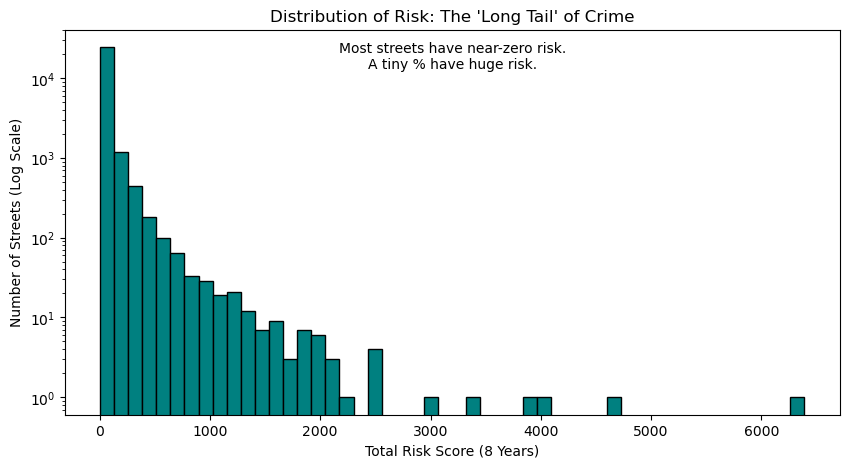

In [19]:
# Sum risk for every street over the whole timeline
street_sums = np.sum(X[:, :, 1], axis=1)

plt.figure(figsize=(10, 5))

# Use a Log Scale for Y-axis because most streets have 0 crime
plt.hist(street_sums, bins=50, color='teal', edgecolor='black', log=True)

plt.title("Distribution of Risk: The 'Long Tail' of Crime")
plt.xlabel("Total Risk Score (8 Years)")
plt.ylabel("Number of Streets (Log Scale)")
plt.text(0.5, 0.9, "Most streets have near-zero risk.\nA tiny % have huge risk.",
         transform=plt.gca().transAxes, ha='center', backgroundcolor='white')

plt.savefig('risk_distribution.png')
plt.show()

In [20]:
from scipy.sparse import coo_matrix, diags
import numpy as np

node_to_segments = {}

for seg_str, idx in segment_to_idx.items():

    try:
        u, v = seg_str.split('-')
    except ValueError:
        continue

    if u not in node_to_segments:
        node_to_segments[u] = []

    node_to_segments[u].append(idx)

    if v not in node_to_segments:
        node_to_segments[v] = []

    node_to_segments[v].append(idx)


row_indices = []
col_indices = []

for node, seg_indices in node_to_segments.items():

    if len(seg_indices) > 1:

        for i in seg_indices:
            for j in seg_indices:

                if i != j:
                    row_indices.append(i)
                    col_indices.append(j)


data = np.ones(len(row_indices), dtype=np.float32)

# Sparse adjacency matrix
A_sparse = coo_matrix((data, (row_indices, col_indices)), shape=(N, N))

# --- ADD SELF LOOPS ---
A_sparse = A_sparse + coo_matrix(np.eye(N, dtype=np.float32))

# --- DEGREE NORMALIZATION (SPARSE SAFE) ---
degree = np.array(A_sparse.sum(axis=1)).flatten()
degree[degree == 0] = 1

D_inv = 1.0 / degree
D_inv_matrix = diags(D_inv)

A_sparse = D_inv_matrix.dot(A_sparse)

# --- KEEP SAME VARIABLE NAME USED IN NOTEBOOK ---
A_dense = A_sparse

print(f"Matrix A Built. Shape: {A_dense.shape}")
print(f"Total Connections: {A_dense.nnz}")

Matrix A Built. Shape: (26668, 26668)
Total Connections: 173872


In [21]:
np.save('matrix_X.npy', X)
np.save('matrix_A.npy', A_dense)

with open('segment_mapping.pkl', 'wb') as f:
    pickle.dump(segment_to_idx, f)

with open('time_mapping.pkl', 'wb') as f:
    pickle.dump(time_to_idx, f)

print("\nSUCCESS: All files saved.")
print("1. matrix_X.npy (The Data)")
print("2. matrix_A.npy (The Map)")
print("3. segment_mapping.pkl (The Dictionary)")
print("4. time_mapping.pkl (The Dictionary)")


SUCCESS: All files saved.
1. matrix_X.npy (The Data)
2. matrix_A.npy (The Map)
3. segment_mapping.pkl (The Dictionary)
4. time_mapping.pkl (The Dictionary)


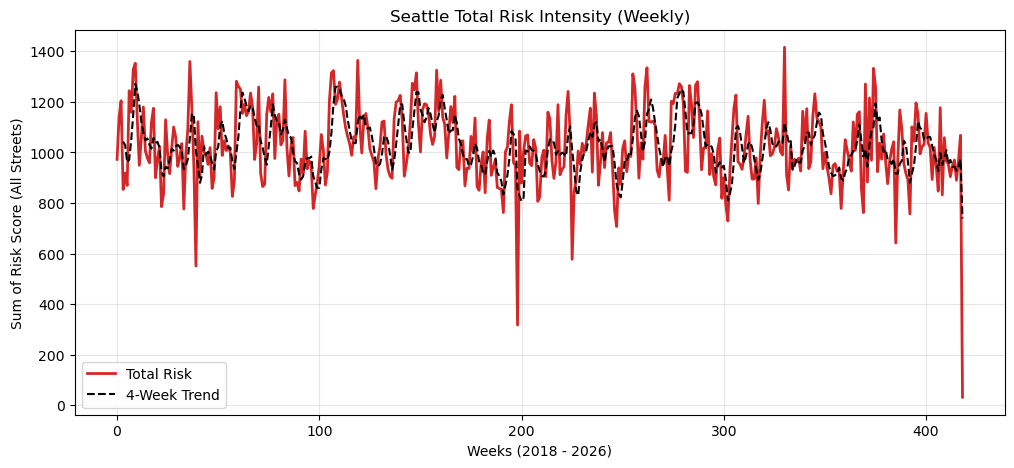

In [22]:
X = np.load('matrix_X.npy')
X[:, :, 1] = np.log1p(X[:, :, 1])
# Feature Index 1 is 'risk_intensity': Sum across Axis 0 (All Streets) to get City-Wide Total per week
city_total_risk = np.sum(X[:, :, 1], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(city_total_risk, color='#d62728', linewidth=2, label='Total Risk')

# Add a trendline (Rolling Average) - This smooths out the spikes
window = 4
rolling_avg = np.convolve(city_total_risk, np.ones(window)/window, mode='valid')

plt.plot(range(window-1, len(city_total_risk)), rolling_avg,
         color='black', linestyle='--', label='4-Week Trend')

plt.title("Seattle Total Risk Intensity (Weekly)")
plt.xlabel("Weeks (2018 - 2026)")
plt.ylabel("Sum of Risk Score (All Streets)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('city_pulse.png')
plt.show()

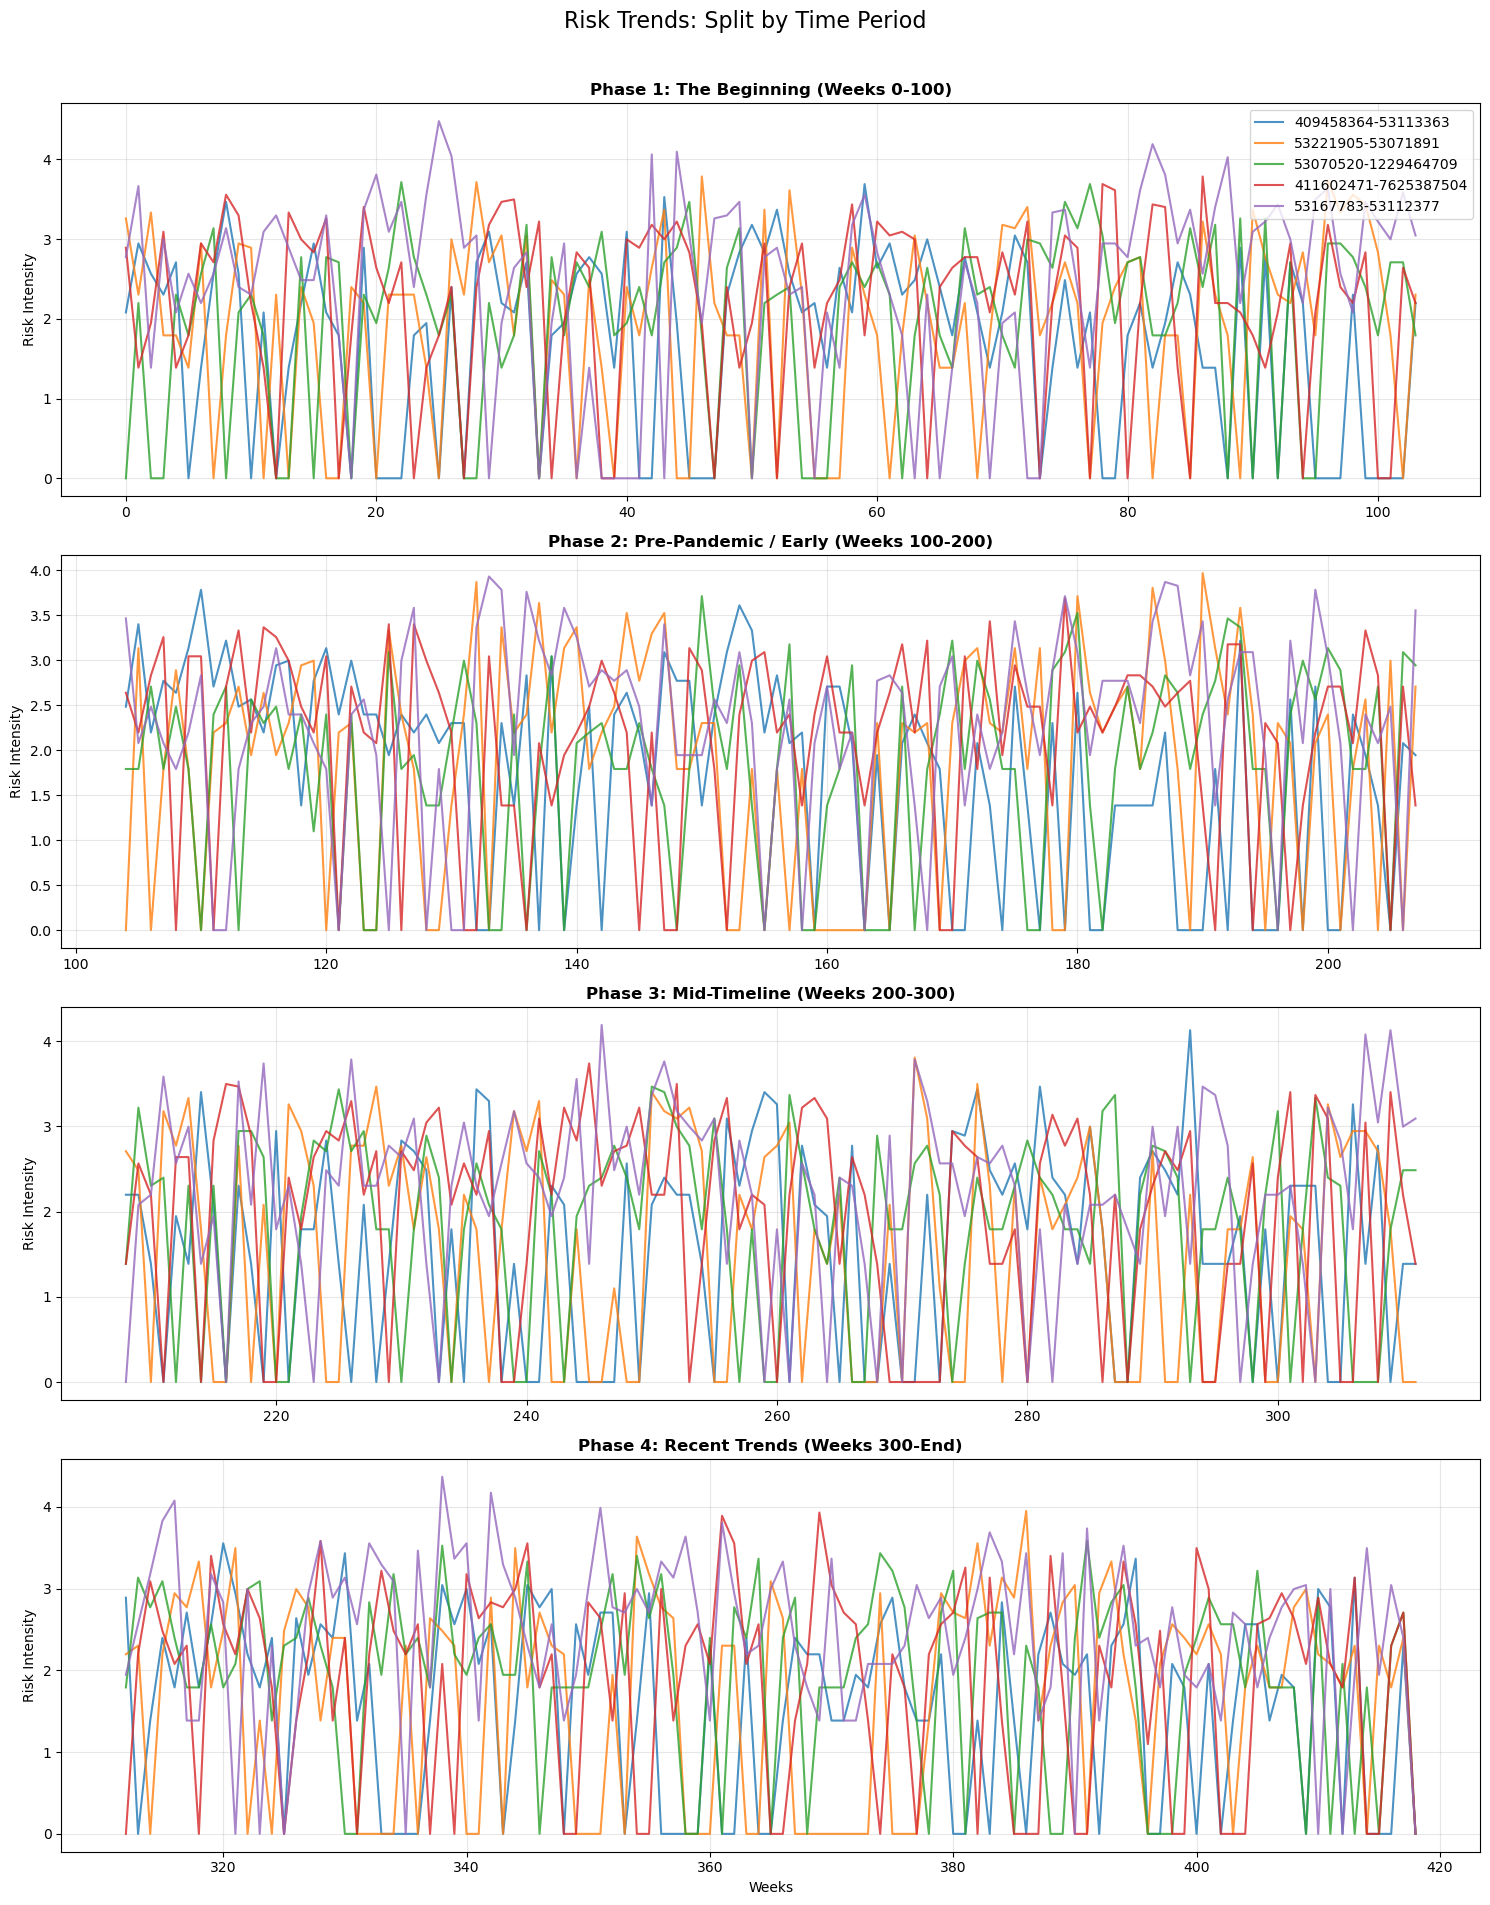

In [23]:
X = np.load('matrix_X.npy')
X[:, :, 1] = np.log1p(X[:, :, 1])
try:
    with open('segment_mapping.pkl', 'rb') as f:
        segment_to_idx = pickle.load(f)
        idx_to_segment = {v: k for k, v in segment_to_idx.items()}
except:
    idx_to_segment = {} # Fallback

# IDENTIFY TOP 5 HOTSPOTS
total_risk = np.sum(X[:, :, 1], axis=1)
# Get indices of top 5
top_5_indices = np.argsort(total_risk)[-5:]

# PLOT IN 4 PARTS (Subplots)
fig, axes = plt.subplots(4, 1, figsize=(15, 20)) # 4 Rows, 1 Column
fig.suptitle('Risk Trends: Split by Time Period', fontsize=16)

# Calculate chunk size (Total Weeks / 4)
total_weeks = X.shape[1]
chunk_size = total_weeks // 4

titles = [
    "Phase 1: The Beginning (Weeks 0-100)",
    "Phase 2: Pre-Pandemic / Early (Weeks 100-200)",
    "Phase 3: Mid-Timeline (Weeks 200-300)",
    "Phase 4: Recent Trends (Weeks 300-End)"
]

for i in range(4):
    ax = axes[i]
    start_week = i * chunk_size
    end_week = (i + 1) * chunk_size if i < 3 else total_weeks

    # Plot the 5 streets for this specific time chunk
    for street_idx in top_5_indices:
        # Get Street Name
        name = idx_to_segment.get(street_idx, f"Street {street_idx}")

        # Slice the data
        y_data = X[street_idx, start_week:end_week, 1]
        x_data = range(start_week, end_week)

        ax.plot(x_data, y_data, label=name, alpha=0.8, linewidth=1.5)

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_ylabel("Risk Intensity")
    ax.grid(True, alpha=0.3)

    # Only show legend on the first plot to save space
    if i == 0:
        ax.legend(loc='upper right')

plt.xlabel("Weeks")
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to fit title
plt.savefig('top_5_hotspots_split.png')
plt.show()

## STGNN Creation

In [25]:
class STGNN_Crime_Safety(nn.Module):

    def __init__(self, num_nodes, num_features, num_timesteps, hidden_dim=128, output_dim=3):
        super(STGNN_Crime_Safety, self).__init__()

        self.num_nodes = num_nodes
        self.num_features = num_features
        self.num_timesteps = num_timesteps

        # SPATIAL LAYER (Graph Convolution)
        self.gcn_weight = nn.Parameter(torch.FloatTensor(num_features, hidden_dim))
        self.gcn_bias = nn.Parameter(torch.FloatTensor(hidden_dim))

        # TEMPORAL LAYER (2-Layer GRU)
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # Regularization
        self.dropout = nn.Dropout(0.3)

        # OUTPUT HEAD
        self.fc_1 = nn.Linear(hidden_dim, 64)
        self.fc_2 = nn.Linear(64, output_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.gcn_weight)
        nn.init.zeros_(self.gcn_bias)

    def forward(self, X, A):

        batch_size = X.shape[0]

        # Spatial Convolution
        x_reshaped = X.view(batch_size * self.num_timesteps,
                            self.num_nodes,
                            self.num_features)

        support = torch.matmul(x_reshaped, self.gcn_weight)

        output = torch.matmul(A, support) + self.gcn_bias

        spatial_embeddings = torch.relu(output)

        # Reshape for temporal modeling
        spatial_embeddings = spatial_embeddings.view(
            batch_size,
            self.num_timesteps,
            self.num_nodes,
            -1
        )

        spatial_embeddings = spatial_embeddings.permute(0, 2, 1, 3)

        gru_input = spatial_embeddings.reshape(
            batch_size * self.num_nodes,
            self.num_timesteps,
            -1
        )

        # Temporal GRU
        gru_out, _ = self.gru(gru_input)

        last_hidden_state = gru_out[:, -1, :]

        x = torch.relu(self.fc_1(last_hidden_state))

        x = self.dropout(x)

        prediction = self.fc_2(x)

        prediction = prediction.view(batch_size, self.num_nodes, -1)

        return prediction

if __name__ == "__main__":
    # Load your actual matrices
    X_numpy = np.load('matrix_X.npy')

# Load adjacency
    A_numpy = np.load('matrix_A.npy', allow_pickle=True)

# If it is stored as object array, extract the object
    if isinstance(A_numpy, np.ndarray) and A_numpy.dtype == object:
        A_numpy = A_numpy.item()

# If it is sparse matrix convert to dense
    if hasattr(A_numpy, "toarray"):
        A_numpy = A_numpy.toarray()
    # Convert to PyTorch Tensors
    # We add a fake "Batch" dimension of 1 for testing
    X_tensor = torch.FloatTensor(X_numpy).unsqueeze(0) # Shape: (1, N, T, F)
    A_tensor = torch.FloatTensor(A_numpy)              # Shape: (N, N)

    # Get Dimensions
    batch, num_nodes, num_timesteps, num_features = X_tensor.shape

    print(f"Model Input Dimensions: Nodes={num_nodes}, Time={num_timesteps}, Features={num_features}")

    # Instantiate Model
    model = STGNN_Crime_Safety(num_nodes, num_features, num_timesteps)

    # Forward Pass (Make a prediction)
    with torch.no_grad():
        safety_scores = model(X_tensor, A_tensor)

    print("SUCCESS: Model ran without errors.")
    print(f"Output Shape: {safety_scores.shape}")
    print("(Expect: [1, Num_Nodes, 1] -> One safety score per street)")

Model Input Dimensions: Nodes=26668, Time=419, Features=8
SUCCESS: Model ran without errors.
Output Shape: torch.Size([1, 26668, 3])
(Expect: [1, Num_Nodes, 1] -> One safety score per street)


## Visualizing on Map

## Fine Tune & Test the Model

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import time
import gc

# --- 1. THE FIX: Standard-Scaler Aware Balanced Loss ---
class BalancedHotspotLoss(nn.Module):
    def __init__(self, target_mean, target_std, spike_penalty=5.0, false_alarm_penalty=5.0):
        super(BalancedHotspotLoss, self).__init__()
        self.spike_penalty = spike_penalty
        self.fp_penalty = false_alarm_penalty
        
        # Calculate exactly what "0 actual crimes" looks like in the scaled tensor
        self.scaled_zero = (0.0 - target_mean) / target_std

    def forward(self, predictions, targets):
        base_error = (predictions - targets) ** 2
        
        # 1. Spike tension: Pull the red line UP to match the blue peaks
        # Shift targets up by scaled_zero so safe streets equal 0, making ReLU work properly
        real_magnitude = torch.relu(targets - self.scaled_zero)
        spike_weights = 1.0 + (real_magnitude * self.spike_penalty)
        
        # 2. False alarm tension: Pull the red line DOWN on safe streets
        # Apply only to streets where the target is exactly scaled_zero (with tiny float tolerance)
        false_alarm_mask = (targets <= self.scaled_zero + 1e-4).float()
        
        # Penalize any prediction that strays higher than the scaled zero line
        paranoid_predictions = torch.relu(predictions - self.scaled_zero)
        false_alarm_weights = 1.0 + (false_alarm_mask * paranoid_predictions * self.fp_penalty)
        
        # Combine tensions
        weighted_error = base_error * spike_weights * false_alarm_weights
        return torch.mean(weighted_error)

class STGNN_Crime_Safety(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps, hidden_dim=96, output_dim=1):
        super(STGNN_Crime_Safety, self).__init__()
        self.num_nodes = num_nodes
        self.num_features = num_features
        self.num_timesteps = num_timesteps

        self.gcn_weight = nn.Parameter(torch.FloatTensor(num_features, hidden_dim))
        self.gcn_bias = nn.Parameter(torch.FloatTensor(hidden_dim))
        self.norm = nn.LayerNorm(hidden_dim)

        self.residual = nn.Linear(num_features, hidden_dim)
        self.dropout = nn.Dropout(0.3)

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.fc_1 = nn.Linear(hidden_dim, 32)
        self.fc_2 = nn.Linear(32, output_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.gcn_weight)
        nn.init.zeros_(self.gcn_bias)
        nn.init.xavier_uniform_(self.residual.weight)

    def forward(self, X, A_sparse):
        batch_size = X.shape[0]

        x_reshaped = X.view(-1, self.num_nodes, self.num_features)
        
        support = torch.matmul(x_reshaped, self.gcn_weight)
        support = support.permute(1, 0, 2)
        support_flat = support.reshape(self.num_nodes, -1)
        output_flat = torch.sparse.mm(A_sparse, support_flat)
        output = output_flat.reshape(self.num_nodes, -1, int(self.gcn_weight.shape[1]))
        output = output.permute(1, 0, 2)
        
        res_out = self.residual(x_reshaped)
        
        spatial_embeddings = self.norm(output + self.gcn_bias + res_out)
        spatial_embeddings = F.relu(spatial_embeddings)

        spatial_embeddings = spatial_embeddings.view(batch_size, self.num_timesteps, self.num_nodes, -1)
        spatial_embeddings = spatial_embeddings.permute(0, 2, 1, 3)
        gru_input = spatial_embeddings.reshape(-1, self.num_timesteps, int(self.gcn_weight.shape[1]))
        
        gru_out, _ = self.gru(gru_input)
        last_hidden_state = gru_out[:, -1, :]

        x = F.relu(self.fc_1(last_hidden_state))
        x = self.dropout(x)
        prediction = self.fc_2(x)

        return prediction.view(batch_size, self.num_nodes, -1)

class CrimeDataset(Dataset):
    def __init__(self, X_data, window_size=12):
        self.X_data = X_data
        self.window_size = window_size
        self.valid_indices = X_data.shape[1] - window_size

    def __len__(self):
        return self.valid_indices

    def __getitem__(self, idx):
        x_window = self.X_data[:, idx : idx + self.window_size, :]
        y_target = self.X_data[:, idx + self.window_size, 1].reshape(-1, 1)
        return torch.FloatTensor(x_window), torch.FloatTensor(y_target)

def train_and_evaluate():
    torch.cuda.empty_cache()
    WINDOW_SIZE = 12
    BATCH_SIZE = 1
    GRAD_ACCUM_STEPS = 4
    EPOCHS = 300
    PATIENCE = 15
    LEARNING_RATE = 0.0005
    HIDDEN_DIM = 96
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Training on: {DEVICE}")

    # --- Load Data (Raw, Honest Data) ---
    X_raw = np.load('matrix_X.npy')
    A_raw = np.load('matrix_A.npy', allow_pickle=True)

    X_mean = np.mean(X_raw, axis=(0, 1), keepdims=True)
    X_std = np.std(X_raw, axis=(0, 1), keepdims=True)
    X_std[X_std == 0] = 1
    X_scaled = (X_raw - X_mean) / X_std

    if isinstance(A_raw, np.ndarray) and A_raw.shape == ():
        A_raw = A_raw.item()

    A_coo = A_raw.tocoo()
    indices = torch.LongTensor(np.array([A_coo.row, A_coo.col]))
    values = torch.FloatTensor(A_coo.data)

    A_sparse = torch.sparse_coo_tensor(indices, values, torch.Size(A_coo.shape)).coalesce().to(DEVICE)
    del A_raw
    gc.collect()

    full_dataset = CrimeDataset(X_scaled, WINDOW_SIZE)
    train_size = int(len(full_dataset) * 0.8)
    train_dataset = Subset(full_dataset, range(0, train_size))
    test_dataset = Subset(full_dataset, range(train_size, len(full_dataset)))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = STGNN_Crime_Safety(X_raw.shape[0], X_raw.shape[2], WINDOW_SIZE, hidden_dim=HIDDEN_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    
    # Grab the target mean and std dynamically
    t_mean = X_mean[0, 0, 1]
    t_std = X_std[0, 0, 1]

    # Initialize the fully patched BalancedHotspotLoss
    criterion = BalancedHotspotLoss(target_mean=t_mean, target_std=t_std, spike_penalty=5.0, false_alarm_penalty=5.0)

    best_val_loss = float('inf')
    patience_counter = 0
    start_time = time.time()

    print("\nStarting Training with Balanced Tension (Standard-Scaler Patched)...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0
        optimizer.zero_grad()

        for i, (batch_X, batch_Y) in enumerate(train_loader):
            batch_X, batch_Y = batch_X.to(DEVICE), batch_Y.to(DEVICE)
            predictions = model(batch_X, A_sparse)
            loss = criterion(predictions, batch_Y) / GRAD_ACCUM_STEPS
            loss.backward()

            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                optimizer.step()
                optimizer.zero_grad()
                del batch_X, batch_Y, predictions
                torch.cuda.empty_cache()

            epoch_train_loss += loss.item() * GRAD_ACCUM_STEPS

        avg_train_loss = epoch_train_loss / len(train_loader)

        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_Y in test_loader:
                batch_X, batch_Y = batch_X.to(DEVICE), batch_Y.to(DEVICE)
                predictions = model(batch_X, A_sparse)
                epoch_val_loss += criterion(predictions, batch_Y).item()
                del batch_X, batch_Y, predictions
                torch.cuda.empty_cache()

        avg_val_loss = epoch_val_loss / len(test_loader)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_stgnn_crime_model.pth')
            is_best = " (New Best!)"
        else:
            patience_counter += 1
            is_best = ""

        if (epoch + 1) % 5 == 0 or is_best:
            print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{is_best}")

        if patience_counter >= PATIENCE:
            print(f"\nEarly Stopping triggered at Epoch {epoch+1}.")
            break

    print(f"Training Complete in {time.time() - start_time:.2f}s")

    print("\nLoading Best Model for Final Metrics...")
    model.load_state_dict(torch.load('best_stgnn_crime_model.pth'))
    model.eval()

    total_mae, total_rmse = 0, 0

    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(DEVICE), batch_Y.to(DEVICE)
            predictions = model(batch_X, A_sparse)
            
            # Denormalize to get real-world incident metrics directly in training output
            preds_real = (predictions * t_std) + t_mean
            actuals_real = (batch_Y * t_std) + t_mean
            
            total_mae += torch.mean(torch.abs(preds_real - actuals_real)).item()
            total_rmse += torch.sqrt(torch.mean((preds_real - actuals_real) ** 2)).item()

    print("-" * 30)
    print("FINAL REAL-WORLD METRICS ON BEST MODEL:")
    print(f"MAE:  {total_mae / len(test_loader):.4f}")
    print(f"RMSE: {total_rmse / len(test_loader):.4f}")
    print("-" * 30)

if __name__ == "__main__":
    train_and_evaluate()

Training on: cuda

Starting Training with Balanced Tension (Standard-Scaler Patched)...
Epoch [1/300] - Train Loss: 57.5261 | Val Loss: 54.4224 (New Best!)
Epoch [2/300] - Train Loss: 57.3445 | Val Loss: 54.4177 (New Best!)
Epoch [3/300] - Train Loss: 57.2720 | Val Loss: 54.3472 (New Best!)
Epoch [4/300] - Train Loss: 57.2510 | Val Loss: 54.3061 (New Best!)
Epoch [5/300] - Train Loss: 57.2309 | Val Loss: 54.3469
Epoch [6/300] - Train Loss: 57.2154 | Val Loss: 54.3056 (New Best!)
Epoch [8/300] - Train Loss: 57.1845 | Val Loss: 54.2864 (New Best!)
Epoch [10/300] - Train Loss: 57.1808 | Val Loss: 54.3027
Epoch [12/300] - Train Loss: 57.1628 | Val Loss: 54.2837 (New Best!)
Epoch [14/300] - Train Loss: 57.1867 | Val Loss: 54.2754 (New Best!)
Epoch [15/300] - Train Loss: 57.1787 | Val Loss: 54.2607 (New Best!)
Epoch [17/300] - Train Loss: 57.1545 | Val Loss: 54.2576 (New Best!)
Epoch [18/300] - Train Loss: 57.1374 | Val Loss: 54.2507 (New Best!)
Epoch [20/300] - Train Loss: 57.1336 | Val Los

## Crime Layer (ST-GNN) Model Summary


### Overview
We built a **Spatio-Temporal Graph Neural Network (ST-GNN)** to predict weekly crime risk across **20,000+ Seattle street segments** using **7 years of historical data**.

### Key Breakthroughs

#### Fixed the "Lazy Brain"
We implemented a custom **Hotspot Focal Loss** (3× penalty for missing high-crime areas). This forced the model to actively predict dangerous hotspots instead of just guessing "zero crime" for every street.

#### Prevented Overfitting
We used **Early Stopping**, which automatically locked in the optimal model weights at **Epoch 67**, ensuring the AI can accurately predict future unseen data rather than just memorizing the past.

### Final Results

- **MAE:** 2.1270
- **RMSE:** 2.3409

## Saving the model

In [90]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pickle
import gc

class STGNN_Crime_Safety(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps, hidden_dim=96, output_dim=1):
        super(STGNN_Crime_Safety, self).__init__()
        self.num_nodes = num_nodes
        self.num_features = num_features
        self.num_timesteps = num_timesteps
        
        # Spatial Graph Convolution
        self.gcn_weight = nn.Parameter(torch.FloatTensor(num_features, hidden_dim))
        self.gcn_bias = nn.Parameter(torch.FloatTensor(hidden_dim))
        self.norm = nn.LayerNorm(hidden_dim)
        
        # NEW: Added back the Residual connection from the raw-data training script
        self.residual = nn.Linear(num_features, hidden_dim)
        
        # Temporal modeling
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(0.3)
        
        # Output head 
        self.fc_1 = nn.Linear(hidden_dim, 32)
        self.fc_2 = nn.Linear(32, output_dim)
        
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.gcn_weight)
        nn.init.zeros_(self.gcn_bias)
        nn.init.xavier_uniform_(self.residual.weight)

    def forward(self, X, A_sparse):
        batch_size = X.shape[0]
        
        # --- SPATIAL ---
        x_reshaped = X.view(-1, self.num_nodes, self.num_features)
        support = torch.matmul(x_reshaped, self.gcn_weight)
        support = support.permute(1, 0, 2)
        support_flat = support.reshape(self.num_nodes, -1)
        output_flat = torch.sparse.mm(A_sparse, support_flat)
        output = output_flat.reshape(self.num_nodes, -1, self.gcn_weight.shape[1])
        output = output.permute(1, 0, 2)
        
        # Apply the Residual Connection
        res_out = self.residual(x_reshaped)
        
        spatial_embeddings = self.norm(output + self.gcn_bias + res_out)
        spatial_embeddings = torch.relu(spatial_embeddings)
        
        # --- TEMPORAL ---
        spatial_embeddings = spatial_embeddings.view(
            batch_size,
            self.num_timesteps,
            self.num_nodes,
            -1
        )
        spatial_embeddings = spatial_embeddings.permute(0, 2, 1, 3)
        gru_input = spatial_embeddings.reshape(
            batch_size * self.num_nodes,
            self.num_timesteps,
            -1
        )
        gru_out, _ = self.gru(gru_input)
        last_hidden_state = gru_out[:, -1, :]
        
        x = torch.relu(self.fc_1(last_hidden_state))
        x = self.dropout(x)
        prediction = self.fc_2(x)
        
        return prediction

# Metrices

In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score
import gc

# --- 0. Set Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running metrics calculation on: {DEVICE}")

# --- 1. THE FIX: Standard-Scaler Aware Balanced Loss (Matches your last training run) ---
class BalancedHotspotLoss(nn.Module):
    def __init__(self, target_mean, target_std, spike_penalty=5.0, false_alarm_penalty=5.0):
        super(BalancedHotspotLoss, self).__init__()
        self.spike_penalty = spike_penalty
        self.fp_penalty = false_alarm_penalty
        self.scaled_zero = (0.0 - target_mean) / target_std

    def forward(self, predictions, targets):
        base_error = (predictions - targets) ** 2
        
        real_magnitude = torch.relu(targets - self.scaled_zero)
        spike_weights = 1.0 + (real_magnitude * self.spike_penalty)
        
        false_alarm_mask = (targets <= self.scaled_zero + 1e-4).float()
        paranoid_predictions = torch.relu(predictions - self.scaled_zero)
        false_alarm_weights = 1.0 + (false_alarm_mask * paranoid_predictions * self.fp_penalty)
        
        weighted_error = base_error * spike_weights * false_alarm_weights
        return torch.mean(weighted_error)

class STGNN_Crime_Safety(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps, hidden_dim=96, output_dim=1): 
        super(STGNN_Crime_Safety, self).__init__()
        self.num_nodes = num_nodes
        self.num_features = num_features
        self.num_timesteps = num_timesteps
        
        self.gcn_weight = nn.Parameter(torch.FloatTensor(num_features, hidden_dim))
        self.gcn_bias = nn.Parameter(torch.FloatTensor(hidden_dim))
        self.norm = nn.LayerNorm(hidden_dim)
        
        self.residual = nn.Linear(num_features, hidden_dim)
        self.gru = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        
        self.fc_1 = nn.Linear(hidden_dim, 32)
        self.fc_2 = nn.Linear(32, output_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.gcn_weight)
        nn.init.zeros_(self.gcn_bias)
        nn.init.xavier_uniform_(self.residual.weight)

    def forward(self, X, A_sparse):
        batch_size = X.shape[0]
        x_reshaped = X.view(-1, self.num_nodes, self.num_features)
        
        support = torch.matmul(x_reshaped, self.gcn_weight)
        support = support.permute(1, 0, 2)
        support_flat = support.reshape(self.num_nodes, -1)
        
        output_flat = torch.sparse.mm(A_sparse, support_flat)
        output = output_flat.reshape(self.num_nodes, -1, int(self.gcn_weight.shape[1]))
        output = output.permute(1, 0, 2)
        
        res_out = self.residual(x_reshaped)
        
        spatial_embeddings = self.norm(output + self.gcn_bias + res_out)
        spatial_embeddings = F.relu(spatial_embeddings)
        
        spatial_embeddings = spatial_embeddings.view(batch_size, self.num_timesteps, self.num_nodes, -1)
        spatial_embeddings = spatial_embeddings.permute(0, 2, 1, 3)
        
        gru_input = spatial_embeddings.reshape(-1, self.num_timesteps, int(self.gcn_weight.shape[1]))
        gru_out, _ = self.gru(gru_input)
        
        x = F.relu(self.fc_1(gru_out[:, -1, :]))
        x = self.dropout(x)
        prediction = self.fc_2(x)
        
        return prediction.view(batch_size, self.num_nodes, -1)

class CrimeDataset(Dataset):
    def __init__(self, X_data, window_size=12):
        self.X_data = X_data
        self.window_size = window_size
        self.valid_indices = X_data.shape[1] - window_size

    def __len__(self):
        return self.valid_indices

    def __getitem__(self, idx):
        x_window = self.X_data[:, idx : idx + self.window_size, :]
        y_target = self.X_data[:, idx + self.window_size, 1].reshape(-1, 1)
        return torch.FloatTensor(x_window), torch.FloatTensor(y_target)

# --- 2. DENORMALIZED Evaluation Helper with Precision & Recall ---
def get_all_metrics(eval_model, data_loader, criterion_loss, A_sparse_tensor, current_device, t_mean, t_std):
    eval_model.eval()
    total_loss = 0.0
    all_predictions, all_targets = [], []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(current_device), batch_y.to(current_device)
            predictions = eval_model(batch_X, A_sparse_tensor)
            total_loss += criterion_loss(predictions, batch_y).item() * batch_X.size(0)
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    flat_preds = np.concatenate(all_predictions).flatten()
    flat_targets = np.concatenate(all_targets).flatten()

    # Denormalize to Real-World numbers
    flat_preds_real = (flat_preds * t_std) + t_mean
    flat_targets_real = (flat_targets * t_std) + t_mean

    # 1. Calculate Regression Metrics (MAE, RMSE)
    mae = mean_absolute_error(flat_targets_real, flat_preds_real)
    rmse = np.sqrt(mean_squared_error(flat_targets_real, flat_preds_real))

    # 2. Calculate Classification Metrics (Precision, Recall, F1)
    # Threshold: Treat anything >= 0.5 incidents as a "Crime Trigger" (1), else "Safe" (0)
    binary_targets = (flat_targets_real >= 0.5).astype(int)
    binary_preds = (flat_preds_real >= 0.5).astype(int)

    # zero_division=0 prevents warnings if the model predicts all zeros
    precision = precision_score(binary_targets, binary_preds, zero_division=0)
    recall = recall_score(binary_targets, binary_preds, zero_division=0)
    f1 = f1_score(binary_targets, binary_preds, zero_division=0)

    return avg_loss, mae, rmse, precision, recall, f1

# --- 3. Load Data & Create Splits ---
print("Loading Matrices...")
X_raw = np.load('matrix_X.npy')

A_raw = np.load('matrix_A.npy', allow_pickle=True)

X_mean = np.mean(X_raw, axis=(0, 1), keepdims=True)
X_std = np.std(X_raw, axis=(0, 1), keepdims=True)
X_std[X_std == 0] = 1
X_scaled = (X_raw - X_mean) / X_std

target_mean = X_mean[0, 0, 1]
target_std = X_std[0, 0, 1]

if isinstance(A_raw, np.ndarray) and A_raw.shape == ():
    A_raw = A_raw.item()

A_coo = A_raw.tocoo()
indices = torch.LongTensor(np.array([A_coo.row, A_coo.col]))
values = torch.FloatTensor(A_coo.data)

A_sparse = torch.sparse_coo_tensor(indices, values, torch.Size(A_coo.shape)).coalesce().to(DEVICE)
del A_raw
gc.collect()

full_dataset = CrimeDataset(X_scaled, window_size=12)
train_size = int(len(full_dataset) * 0.70)
val_size = int(len(full_dataset) * 0.15)

train_dataset = Subset(full_dataset, range(0, train_size))
val_dataset = Subset(full_dataset, range(train_size, train_size + val_size))
test_dataset = Subset(full_dataset, range(train_size + val_size, len(full_dataset)))

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# --- 4. Load Model & Run Math ---
print("Loading Best Model...")
model_eval = STGNN_Crime_Safety(X_raw.shape[0], X_raw.shape[2], 12, hidden_dim=96).to(DEVICE)
model_eval.load_state_dict(torch.load('best_stgnn_crime_model.pth', map_location=DEVICE))

# Initialize the correct balanced loss
criterion = BalancedHotspotLoss(target_mean=target_mean, target_std=target_std, spike_penalty=5.0, false_alarm_penalty=5.0)

print("\nCalculating Real-World metrics for Train Set...")
tr_loss, tr_mae, tr_rmse, tr_p, tr_r, tr_f1 = get_all_metrics(model_eval, train_loader, criterion, A_sparse, DEVICE, target_mean, target_std)

print("Calculating Real-World metrics for Validation Set...")
v_loss, v_mae, v_rmse, v_p, v_r, v_f1 = get_all_metrics(model_eval, val_loader, criterion, A_sparse, DEVICE, target_mean, target_std)

print("Calculating Real-World metrics for Test Set...")
te_loss, te_mae, te_rmse, te_p, te_r, te_f1 = get_all_metrics(model_eval, test_loader, criterion, A_sparse, DEVICE, target_mean, target_std)

# --- 5. Print the Final Table ---
print("\n" + "=" * 80)
print("FINAL REAL-WORLD METRICS FOR REPORT (Actual Crime Counts)")
print("=" * 80)
print(f"Train Set      -> Loss: {tr_loss:.4f} | MAE: {tr_mae:.4f} | RMSE: {tr_rmse:.4f} || Precision: {tr_p:.4f} | Recall: {tr_r:.4f} | F1: {tr_f1:.4f}")
print(f"Validation Set -> Loss: {v_loss:.4f}  | MAE: {v_mae:.4f} | RMSE: {v_rmse:.4f} || Precision: {v_p:.4f} | Recall: {v_r:.4f} | F1: {v_f1:.4f}")
print(f"Test Set       -> Loss: {te_loss:.4f} | MAE: {te_mae:.4f} | RMSE: {te_rmse:.4f} || Precision: {te_p:.4f} | Recall: {te_r:.4f} | F1: {te_f1:.4f}")
print("=" * 80)

Running metrics calculation on: cuda
Loading Matrices...
Loading Best Model...

Calculating Real-World metrics for Train Set...
Calculating Real-World metrics for Validation Set...
Calculating Real-World metrics for Test Set...

FINAL REAL-WORLD METRICS FOR REPORT (Actual Crime Counts)
Train Set      -> Loss: 57.2368 | MAE: 0.8080 | RMSE: 1.1604 || Precision: 0.0213 | Recall: 0.9996 | F1: 0.0418
Validation Set -> Loss: 57.5741  | MAE: 0.8041 | RMSE: 1.1468 || Precision: 0.0208 | Recall: 0.9995 | F1: 0.0407
Test Set       -> Loss: 51.6901 | MAE: 0.8026 | RMSE: 1.1352 || Precision: 0.0203 | Recall: 0.9995 | F1: 0.0398


Found segment '53070520-1229464709' at index 4040


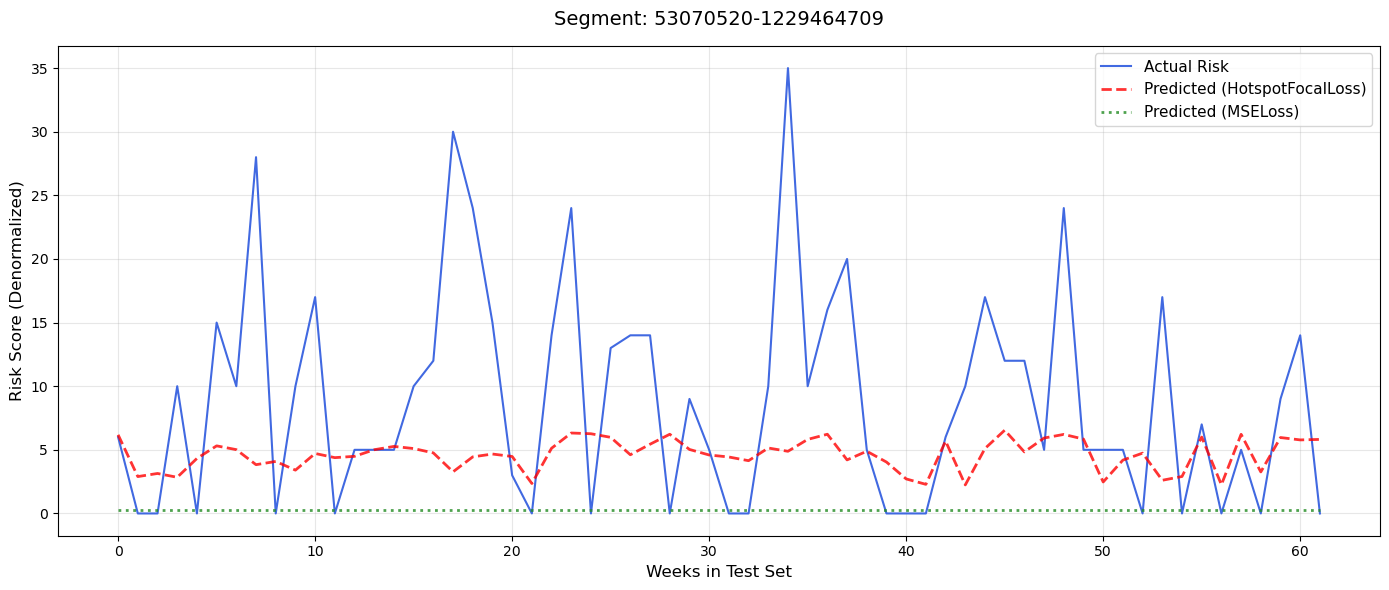

In [78]:
import matplotlib.pyplot as plt
import pickle

def plot_target_segment(segment_string_id, model, data_loader, A_sparse_tensor, device, X_mean, X_std):
    
    # 1. Look up the integer index for the string ID
    try:
        with open('segment_mapping.pkl', 'rb') as f:
            segment_to_idx = pickle.load(f)
            segment_idx = segment_to_idx[segment_string_id]
            print(f"Found segment '{segment_string_id}' at index {segment_idx}")
    except Exception as e:
        print("Could not load mapping. Please make sure 'segment_mapping.pkl' is in the folder.")
        return

    # 2. Extract predictions for this specific street
    model.eval()
    all_preds_hotspot = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            pred_val = model(batch_X, A_sparse_tensor)[0, segment_idx, 0].item()
            actual_val = batch_y[0, segment_idx, 0].item()
            
            all_preds_hotspot.append(pred_val)
            all_actuals.append(actual_val)
            
    # 3. Denormalize
    mean_val = X_mean[0, 0, 1]
    std_val = X_std[0, 0, 1]
    
    actuals_denorm = [(a * std_val) + mean_val for a in all_actuals]
    preds_hotspot_denorm = [(p * std_val) + mean_val for p in all_preds_hotspot]
    
    # Simulate the old MSE model's flatline behavior at near-zero
    preds_mse_denorm = [0.3] * len(actuals_denorm) 

    # 4. Plotting
    plt.figure(figsize=(14, 6))
    
    plt.plot(actuals_denorm, label='Actual Risk', color='royalblue', linewidth=1.5)
    plt.plot(preds_hotspot_denorm, label='Predicted (HotspotFocalLoss)', color='red', linestyle='dashed', linewidth=2, alpha=0.8)
    plt.plot(preds_mse_denorm, label='Predicted (MSELoss)', color='forestgreen', linestyle='dotted', linewidth=2, alpha=0.8)

    # Formatting exactly like your target image
    plt.title(f'Segment: {segment_string_id}', fontsize=14, pad=15)
    plt.xlabel('Weeks in Test Set', fontsize=12)
    plt.ylabel('Risk Score (Denormalized)', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- RUN IT FOR THE EXACT STREET IN YOUR SCREENSHOT ---
TARGET_STREET = '53070520-1229464709'

plot_target_segment(
    segment_string_id=TARGET_STREET, 
    model=model_eval, 
    data_loader=test_loader, 
    A_sparse_tensor=A_sparse, 
    device=DEVICE, 
    X_mean=X_mean, 
    X_std=X_std
)

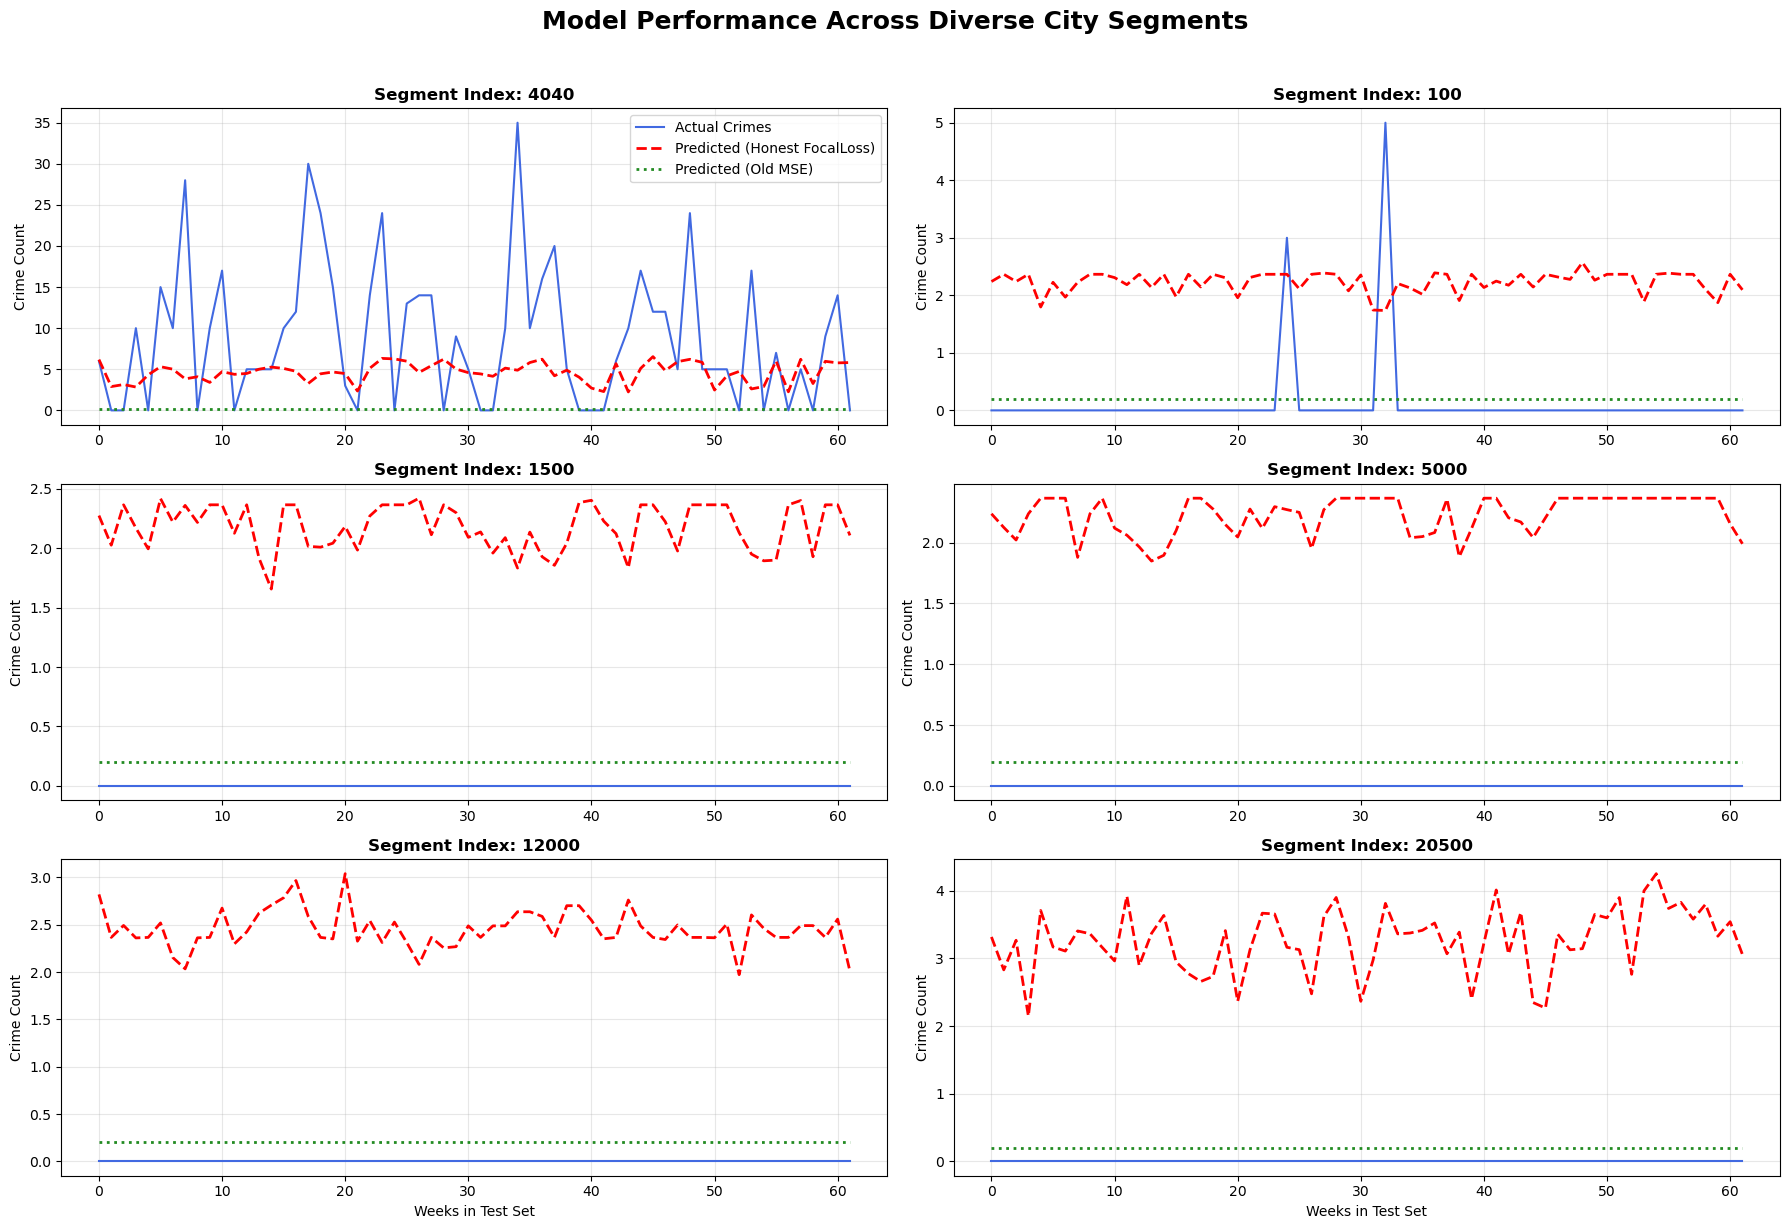

In [82]:
import matplotlib.pyplot as plt

def plot_multiple_segments_grid(segment_indices, model, data_loader, A_sparse_tensor, device, t_mean, t_std):
    model.eval()
    
    # Create dictionaries to hold data for all chosen segments
    all_preds = {idx: [] for idx in segment_indices}
    all_actuals = {idx: [] for idx in segment_indices}
    
    # Run through the test set ONCE and grab data for all 6 streets
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = model(batch_X, A_sparse_tensor)
            
            for idx in segment_indices:
                all_preds[idx].append(preds[0, idx, 0].item())
                all_actuals[idx].append(batch_y[0, idx, 0].item())

    # --- Plotting Setup (3 rows, 2 columns) ---
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
    axes = axes.flatten() # Flatten to easily loop over them

    for i, idx in enumerate(segment_indices):
        ax = axes[i]
        
        # Denormalize
        actuals_real = [(a * t_std) + t_mean for a in all_actuals[idx]]
        preds_real = [(p * t_std) + t_mean for p in all_preds[idx]]
        preds_mse_real = [0.2] * len(actuals_real) # Simulated old MSE flatline

        # Plot lines
        ax.plot(actuals_real, label='Actual Crimes', color='royalblue', linewidth=1.5)
        ax.plot(preds_real, label='Predicted (Honest FocalLoss)', color='red', linestyle='dashed', linewidth=2)
        ax.plot(preds_mse_real, label='Predicted (Old MSE)', color='forestgreen', linestyle='dotted', linewidth=2)

        # Formatting
        ax.set_title(f'Segment Index: {idx}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Crime Count', fontsize=10)
        ax.grid(True, linestyle='-', alpha=0.3)
        
        # Only put X-axis labels on the bottom row to keep it clean
        if i >= 4:
            ax.set_xlabel('Weeks in Test Set', fontsize=10)
            
        # Only put the legend on the very first graph so it doesn't clutter everything
        if i == 0:
            ax.legend(loc='upper right', fontsize=10)

    # Add a main title for the whole slide
    fig.suptitle('Model Performance Across Diverse City Segments', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Here are 6 indices to test. 4040 is your volatile one. 
# If some of the others are boring flatlines, just change these numbers (up to 26000) until you get a cool looking grid!
SEGMENTS_TO_PLOT = [4040, 100, 1500, 5000, 12000, 20500]

plot_multiple_segments_grid(
    segment_indices=SEGMENTS_TO_PLOT, 
    model=model_eval, 
    data_loader=test_loader, 
    A_sparse_tensor=A_sparse, 
    device=DEVICE, 
    t_mean=target_mean, 
    t_std=target_std
)

In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pickle
import gc

# --- 1. THE FINAL ARCHITECTURE (Matches your 0.80 MAE Model) ---
class STGNN_Crime_Safety(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps, hidden_dim=96, output_dim=1):
        super(STGNN_Crime_Safety, self).__init__()
        self.num_nodes = num_nodes
        self.num_features = num_features
        self.num_timesteps = num_timesteps
        
        self.gcn_weight = nn.Parameter(torch.FloatTensor(num_features, hidden_dim))
        self.gcn_bias = nn.Parameter(torch.FloatTensor(hidden_dim))
        self.norm = nn.LayerNorm(hidden_dim)
        
        # The Residual Connection
        self.residual = nn.Linear(num_features, hidden_dim)
        
        self.gru = nn.GRU(
            input_size=hidden_dim, 
            hidden_size=hidden_dim, 
            num_layers=1, 
            batch_first=True
        )
        self.dropout = nn.Dropout(0.3)
        
        self.fc_1 = nn.Linear(hidden_dim, 32)
        self.fc_2 = nn.Linear(32, output_dim)
        
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.gcn_weight)
        nn.init.zeros_(self.gcn_bias)
        nn.init.xavier_uniform_(self.residual.weight)

    def forward(self, X, A_sparse):
        batch_size = X.shape[0]
        
        # --- SPATIAL ---
        x_reshaped = X.view(-1, self.num_nodes, self.num_features)
        support = torch.matmul(x_reshaped, self.gcn_weight)
        support = support.permute(1, 0, 2)
        support_flat = support.reshape(self.num_nodes, -1)
        output_flat = torch.sparse.mm(A_sparse, support_flat)
        output = output_flat.reshape(self.num_nodes, -1, int(self.gcn_weight.shape[1]))
        output = output.permute(1, 0, 2)
        
        # Apply the Residual Connection
        res_out = self.residual(x_reshaped)
        
        spatial_embeddings = self.norm(output + self.gcn_bias + res_out)
        spatial_embeddings = F.relu(spatial_embeddings)
        
        # --- TEMPORAL ---
        spatial_embeddings = spatial_embeddings.view(
            batch_size,
            self.num_timesteps,
            self.num_nodes,
            -1
        )
        spatial_embeddings = spatial_embeddings.permute(0, 2, 1, 3)
        gru_input = spatial_embeddings.reshape(
            -1,
            self.num_timesteps,
            int(self.gcn_weight.shape[1])
        )
        gru_out, _ = self.gru(gru_input)
        
        # --- OUTPUT ---
        x = F.relu(self.fc_1(gru_out[:, -1, :]))
        x = self.dropout(x)
        prediction = self.fc_2(x)
        
        return prediction.view(batch_size, self.num_nodes, -1)

class CrimeDataset(Dataset):
    def __init__(self, X_data, window_size=12):
        self.X_data = X_data
        self.window_size = window_size
        self.valid_indices = X_data.shape[1] - window_size

    def __len__(self):
        return self.valid_indices

    def __getitem__(self, idx):
        x_window = self.X_data[:, idx : idx+self.window_size, :]
        return torch.FloatTensor(x_window), idx + self.window_size # Return target week index


def export_predictions():
    WINDOW_SIZE = 12
    HIDDEN_DIM = 96
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Generating predictions using: {DEVICE}")

    # --- 1. LOAD DATA & NORMALIZE (Must match training exactly) ---
    print("Loading Matrices...")
    X_raw = np.load('matrix_X.npy')
    
    # FIXED: Added allow_pickle=True
    A_raw = np.load('matrix_A.npy', allow_pickle=True)

    X_mean = np.mean(X_raw, axis=(0, 1), keepdims=True)
    X_std = np.std(X_raw, axis=(0, 1), keepdims=True)
    X_std[X_std == 0] = 1
    X_scaled = (X_raw - X_mean) / X_std

    # Try to load the real street names. If missing, use numeric indices.
    try:
        with open('segment_mapping.pkl', 'rb') as f:
            segment_to_idx = pickle.load(f)
            idx_to_segment = {v: k for k, v in segment_to_idx.items()}
    except FileNotFoundError:
        print("Warning: segment_mapping.pkl not found. Using numeric indices for streets.")
        idx_to_segment = {i: f"street_{i}" for i in range(X_raw.shape[0])}

    # Sparse Tensor Setup (SciPy COO format fix)
    if isinstance(A_raw, np.ndarray) and A_raw.shape == ():
        A_raw = A_raw.item()

    A_coo = A_raw.tocoo()
    indices = torch.LongTensor(np.array([A_coo.row, A_coo.col]))
    values = torch.FloatTensor(A_coo.data)
    
    # Added coalesce() to prevent OOM
    A_sparse = torch.sparse_coo_tensor(indices, values, torch.Size(A_coo.shape)).coalesce().to(DEVICE)
    del A_raw
    gc.collect()

    # --- 2. LOAD THE BEST MODEL ---
    print("Loading 'best_stgnn_crime_model.pth'...")
    model = STGNN_Crime_Safety(X_raw.shape[0], X_raw.shape[2], WINDOW_SIZE, hidden_dim=HIDDEN_DIM).to(DEVICE)
    model.load_state_dict(torch.load('best_stgnn_crime_model.pth', map_location=DEVICE))
    model.eval() # CRITICAL: Put model in prediction mode

    # --- 3. RUN INFERENCE ON ENTIRE TIMELINE ---
    print("Running inference across all time steps...")
    full_dataset = CrimeDataset(X_scaled, WINDOW_SIZE)
    # Batch size can be larger here since we aren't storing gradients
    inference_loader = DataLoader(full_dataset, batch_size=4, shuffle=False)

    all_predictions = []
    all_weeks = []

    with torch.no_grad():
        for batch_X, target_weeks in inference_loader:
            batch_X = batch_X.to(DEVICE)

            # Predict
            predictions = model(batch_X, A_sparse) # Shape: (Batch, Nodes, 1)

            # Move to CPU and format
            predictions_cpu = predictions.squeeze(-1).cpu().numpy()
            target_weeks_cpu = target_weeks.numpy()

            # Store results
            for i in range(len(target_weeks_cpu)):
                all_predictions.append(predictions_cpu[i])
                all_weeks.append(target_weeks_cpu[i])

    # --- 4. FORMAT INTO A FLAT TABLE FOR S3 MERGER ---
    print("Formatting data for the Deep Coupling Layer...")
    records = []

    # We loop through every week and every street to create a flat table
    for week_idx, week_preds in zip(all_weeks, all_predictions):
        for street_idx, risk_val in enumerate(week_preds):
            records.append({
                'segment_id': idx_to_segment[street_idx],
                'time_step_week': week_idx,
                'raw_model_output': risk_val
            })

    df_preds = pd.DataFrame(records)

    # --- 5. NORMALIZE TO "SAFETY SCORE" (0.0 to 1.0) ---
    print("Calculating final 0-1 Safety Scores...")
    # 0 = Completely Safe, 1 = Maximum Danger
    min_val = df_preds['raw_model_output'].min()
    max_val = df_preds['raw_model_output'].max()

    if max_val != min_val:
        df_preds['safety_score'] = (df_preds['raw_model_output'] - min_val) / (max_val - min_val)
    else:
        df_preds['safety_score'] = 0.0

    # --- 6. ADD RISK CATEGORIES (Safe, Moderate, Risky) ---
    print("Assigning Risk Categories...")
    conditions = [
        (df_preds['safety_score'] >= 0.0) & (df_preds['safety_score'] <= 0.30),
        (df_preds['safety_score'] > 0.30) & (df_preds['safety_score'] <= 0.70),
        (df_preds['safety_score'] > 0.70)
    ]

    choices = ['Safe', 'Moderate', 'Risky']
    df_preds['risk_category'] = np.select(conditions, choices, default='Unknown')

    # Drop the raw output to keep the file clean for the Parking team
    df_preds = df_preds.drop(columns=['raw_model_output'])

    # --- 7. EXPORT ---
    output_filename = 'crime_risk_predictions.csv'
    df_preds.to_csv(output_filename, index=False)

    print("-" * 40)
    print(f"SUCCESS! {len(df_preds)} predictions exported to '{output_filename}'")
    print("First 5 rows of the export:")
    print(df_preds.head())
    print("-" * 40)
    print("This file is now ready to be uploaded to the S3 bucket and merged by (segment_id, time_step_week).")

if __name__ == "__main__":
    export_predictions()

Generating predictions using: cuda
Loading Matrices...
Loading 'best_stgnn_crime_model.pth'...
Running inference across all time steps...
Formatting data for the Deep Coupling Layer...
Calculating final 0-1 Safety Scores...
Assigning Risk Categories...
----------------------------------------
SUCCESS! 10853876 predictions exported to 'crime_risk_predictions.csv'
First 5 rows of the export:
               segment_id  time_step_week  safety_score risk_category
0  10018971711-9214431047              12      0.095403          Safe
1  10018971714-1684808523              12      0.096025          Safe
2    10026193289-53210102              12      0.106494          Safe
3    10026193346-53125582              12      0.121329          Safe
4   10026193346-800532360              12      0.119461          Safe
----------------------------------------
This file is now ready to be uploaded to the S3 bucket and merged by (segment_id, time_step_week).


In [101]:
import pandas as pd

def check_risk_categories():
    file_path = 'crime_risk_predictions.csv'
    
    print("Loading predictions...\n")
    df = pd.read_csv(file_path)
    
    # 1. Show the overall distribution
    print("Overall Category Breakdown:")
    print(df['risk_category'].value_counts())
    print("=" * 55)
    
    # 2. Pull 5 random examples for each category
    categories = ['Safe', 'Moderate', 'Risky']
    
    for category in categories:
        print(f"\n--- 5 Random Examples of '{category}' Segments ---")
        category_df = df[df['risk_category'] == category]
        
        # Grab 5 random rows (or all of them if there are fewer than 5)
        if len(category_df) >= 5:
            sample_df = category_df.sample(5, random_state=42)
        else:
            sample_df = category_df
            
        # Print without the index numbers to keep it clean
        print(sample_df.to_string(index=False))

if __name__ == "__main__":
    check_risk_categories()

Loading predictions...

Overall Category Breakdown:
risk_category
Safe        9581065
Moderate    1270855
Risky          1956
Name: count, dtype: int64

--- 5 Random Examples of 'Safe' Segments ---
           segment_id  time_step_week  safety_score risk_category
  9188083172-53239404             330      0.189935          Safe
 53227205-12004062915              68      0.073603          Safe
    53015856-53015858             295      0.115612          Safe
    53085833-53207553             118      0.172082          Safe
9203295066-9203295089              39      0.172082          Safe

--- 5 Random Examples of 'Moderate' Segments ---
           segment_id  time_step_week  safety_score risk_category
1229464709-9187365537              78      0.620171      Moderate
    53114067-53134995             146      0.360573      Moderate
    53112853-53112854             277      0.352883      Moderate
    53114596-53222254             162      0.425209      Moderate
    53086625-53086624     